# 🏠 House Price Prediction

## End-to-End Machine Learning Web Application

### Author

Andrew Asem

### Technologies

- Python
- Pandas
- NumPy
- Scikit-learn
- FastAPI
- React
- TypeScript

---

## Project Overview

This project aims to develop an end-to-end machine learning web application that predicts house prices based on property features.

The project includes:

- Data Exploration
- Data Cleaning
- Feature Engineering
- Model Training
- Model Evaluation
- FastAPI Backend
- React Frontend

The final solution will allow users to enter house information through a web interface and receive an estimated house price using the best-performing regression model.

# 1. Business Problem

Accurately estimating house prices is important for buyers, sellers, and real estate agencies.

Manual estimation is often subjective and time-consuming. Machine learning models can analyze historical housing data and learn relationships between property features and market prices, providing faster and more consistent price estimates.

# 2. Project Objectives

The objectives of this project are:

- Explore and understand the dataset.
- Clean and preprocess the data.
- Perform feature engineering.
- Train multiple regression models.
- Compare model performance.
- Select the best model.
- Build a FastAPI prediction API.
- Develop a React frontend for predictions.

# 3. Import Libraries

In [1]:
# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

# Data manipulation
import numpy as np
import pandas as pd

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Configure plots
plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

# Display options
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 10)

# 4. Load Dataset

In this section, we load the dataset into a pandas DataFrame and verify that it has been loaded correctly by displaying its dimensions and the first few rows.

In [2]:
# Load the dataset
df = pd.read_csv("data/house_prices.csv")

# Display dataset shape
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

# Display first 5 rows
df.head()

Rows: 187531
Columns: 21


,Index,Title,Description,Amount(in rupees),Price (in rupees),location,Carpet Area,Status,Floor,Transaction,Furnishing,facing,overlooking,Society,Bathroom,Balcony,Car Parking,Ownership,Super Area,Dimensions,Plot Area
0,0,1 BHK Ready to Occupy Flat for sale in Srushti...,"Bhiwandi, Thane has an attractive 1 BHK Flat f...",42 Lac,6000.0,thane,500 sqft,Ready to Move,10 out of 11,Resale,Unfurnished,NaN,NaN,Srushti Siddhi Mangal Murti Complex,1,2,NaN,NaN,NaN,NaN,NaN
1,1,2 BHK Ready to Occupy Flat for sale in Dosti V...,One can find this stunning 2 BHK flat for sale...,98 Lac,13799.0,thane,473 sqft,Ready to Move,3 out of 22,Resale,Semi-Furnished,East,Garden/Park,Dosti Vihar,2,NaN,1 Open,Freehold,NaN,NaN,NaN
2,2,2 BHK Ready to Occupy Flat for sale in Sunrise...,Up for immediate sale is a 2 BHK apartment in ...,1.40 Cr,17500.0,thane,779 sqft,Ready to Move,10 out of 29,Resale,Unfurnished,East,Garden/Park,Sunrise by Kalpataru,2,NaN,1 Covered,Freehold,NaN,NaN,NaN
3,3,1 BHK Ready to Occupy Flat for sale Kasheli,This beautiful 1 BHK Flat is available for sal...,25 Lac,NaN,thane,530 sqft,Ready to Move,1 out of 3,Resale,Unfurnished,NaN,NaN,NaN,1,1,NaN,NaN,NaN,NaN,NaN
4,4,2 BHK Ready to Occupy Flat for sale in TenX Ha...,"This lovely 2 BHK Flat in Pokhran Road, Thane ...",1.60 Cr,18824.0,thane,635 sqft,Ready to Move,20 out of 42,Resale,Unfurnished,West,"Garden/Park, Main Road",TenX Habitat Raymond Realty,2,NaN,1 Covered,Co-operative Society,NaN,NaN,NaN


# 5. Dataset Information

Understanding the dataset structure is the first step in any machine learning project.

We inspect:

- Number of rows and columns
- Data types
- Missing values
- Memory usage

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 187531 entries, 0 to 187530
Data columns (total 21 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Index              187531 non-null  int64  
 1   Title              187531 non-null  str    
 2   Description        184508 non-null  str    
 3   Amount(in rupees)  187531 non-null  str    
 4   Price (in rupees)  169866 non-null  float64
 5   location           187531 non-null  str    
 6   Carpet Area        106858 non-null  str    
 7   Status             186916 non-null  str    
 8   Floor              180454 non-null  str    
 9   Transaction        187448 non-null  str    
 10  Furnishing         184634 non-null  str    
 11  facing             117298 non-null  str    
 12  overlooking        106095 non-null  str    
 13  Society            77853 non-null   str    
 14  Bathroom           186703 non-null  str    
 15  Balcony            138596 non-null  str    
 16  Car Parking  

# 6. Statistical Summary

The statistical summary provides an overview of the numerical features, including:

- Count
- Mean
- Standard Deviation
- Minimum
- Quartiles
- Maximum

In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Index,187531.0,93765.000000,54135.681003,0.0,46882.5,93765.0,140647.5,187530.0
Price (in rupees),169866.0,7583.771885,27241.705819,0.0,4297.0,6034.0,9450.0,6700000.0
Dimensions,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Plot Area,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# 7. Missing Values

Before building any model, we check whether the dataset contains missing values that need to be handled.

In [6]:
missing_values = df.isnull().sum()

missing_values[missing_values > 0].sort_values(ascending=False)

Plot Area      187531
Dimensions     187531
Society        109678
Super Area     107685
Car Parking    103357
                ...  
Description      3023
Furnishing       2897
Bathroom          828
Status            615
Transaction        83
Length: 17, dtype: int64

# 8. Duplicate Records

Duplicate records can negatively affect model performance. We check whether duplicate rows exist in the dataset.

In [8]:
duplicates = df.duplicated().sum()

print(f"Duplicate rows: {duplicates}")

Duplicate rows: 0


# 9. Dataset Columns

Display all feature names before beginning exploratory data analysis.

In [9]:
for i, column in enumerate(df.columns, start=1):
    print(f"{i}. {column}")

1. Index
2. Title
3. Description
4. Amount(in rupees)
5. Price (in rupees)
6. location
7. Carpet Area
8. Status
9. Floor
10. Transaction
11. Furnishing
12. facing
13. overlooking
14. Society
15. Bathroom
16. Balcony
17. Car Parking
18. Ownership
19. Super Area
20. Dimensions
21. Plot Area


# 10. Data Dictionary

The following table summarizes the dataset columns, their data types, the percentage of missing values, and a brief description of their purpose in the project.

This helps us identify which features are useful, which require preprocessing, and which may need to be removed.

In [12]:
data_dictionary = pd.DataFrame({
    "Column": df.columns,
    "Data Type": df.dtypes.astype(str),
    "Missing Values": df.isnull().sum(),
    "Missing (%)": (df.isnull().mean() * 100).round(2)
})

data_dictionary.reset_index(drop=True, inplace=True)

data_dictionary

,Column,Data Type,Missing Values,Missing (%)
0,Index,int64,0,0.00
1,Title,str,0,0.00
2,Description,str,3023,1.61
3,Amount(in rupees),str,0,0.00
4,Price (in rupees),float64,17665,9.42
...,...,...,...,...
16,Car Parking,str,103357,55.11
17,Ownership,str,65517,34.94
18,Super Area,str,107685,57.42
19,Dimensions,float64,187531,100.00


# 11. Feature Classification

Each feature is classified according to its role in the machine learning pipeline.

In [13]:
feature_info = pd.DataFrame({
    "Feature": df.columns,
    "Role": [
        "Identifier",          # Index
        "Text",
        "Text",
        "Target",
        "Numeric Feature",
        "Categorical",
        "Text Numeric",
        "Categorical",
        "Text Numeric",
        "Categorical",
        "Categorical",
        "Categorical",
        "Categorical",
        "Categorical",
        "Text Numeric",
        "Text Numeric",
        "Categorical",
        "Categorical",
        "Text Numeric",
        "Drop",
        "Drop"
    ]
})

feature_info

,Feature,Role
0,Index,Identifier
1,Title,Text
2,Description,Text
3,Amount(in rupees),Target
4,Price (in rupees),Numeric Feature
...,...,...
16,Car Parking,Categorical
17,Ownership,Categorical
18,Super Area,Text Numeric
19,Dimensions,Drop


# 12. Feature Engineering - Target Variable

The target variable (`Amount(in rupees)`) is stored as text using Indian numbering units such as **Lac** and **Cr**.

Before training a regression model, these values must be converted into numeric values representing the total price in Indian Rupees (INR).

Examples:

- 42 Lac → 4,200,000
- 1.40 Cr → 14,000,000

In [14]:
def convert_price(price):
    """
    Convert prices stored as text (e.g., '42 Lac', '1.40 Cr')
    into numeric values in Indian Rupees.
    """

    if pd.isna(price):
        return np.nan

    price = str(price).strip()

    if "Cr" in price:
        return float(price.replace("Cr", "").strip()) * 10_000_000

    elif "Lac" in price:
        return float(price.replace("Lac", "").strip()) * 100_000

    else:
        try:
            return float(price)
        except:
            return np.nan

## Apply the Conversion

Create a new numeric target column while preserving the original text column for reference.

In [15]:
df["Price_INR"] = df["Amount(in rupees)"].apply(convert_price)

df[["Amount(in rupees)", "Price_INR"]].head(10)

,Amount(in rupees),Price_INR
0,42 Lac,4200000.0
1,98 Lac,9800000.0
2,1.40 Cr,14000000.0
3,25 Lac,2500000.0
4,1.60 Cr,16000000.0
5,45 Lac,4500000.0
6,16.5 Lac,1650000.0
7,60 Lac,6000000.0
8,60 Lac,6000000.0
9,1.60 Cr,16000000.0


## Validate the Conversion

Verify that the conversion was performed correctly by checking summary statistics and sample values.

In [16]:
df["Price_INR"].describe()

count    1.778470e+05
mean     1.198134e+07
std      3.943827e+07
min      1.000000e+05
25%      4.840000e+06
50%      7.800000e+06
75%      1.450000e+07
max      1.400300e+10
Name: Price_INR, dtype: float64

# 13. Validate the Target Variable

Before training any machine learning model, it is important to inspect the target variable for unusual or extreme values.

Outliers may represent:

- Luxury properties
- Data entry errors
- Incorrect unit conversions

We investigate these values before deciding how to handle them.

In [17]:
# Display the 10 most expensive properties

df.sort_values("Price_INR", ascending=False)[
    [
        "Amount(in rupees)",
        "Price_INR",
        "Title",
        "location"
    ]
].head(10)

,Amount(in rupees),Price_INR,Title,location
181234,1400.30 Cr,1.400300e+10,3 BHK Ready to Occupy Flat for sale in Nest Ha...,vadodara
176536,510.04 Cr,5.100400e+09,3 BHK Ready to Occupy Flat for sale Hill Cart ...,siliguri
174894,396.75 Cr,3.967500e+09,2 BHK Ready to Occupy Flat for sale Kachna Road,raipur
175013,229.80 Cr,2.298000e+09,2 BHK Ready to Occupy Flat for sale in Chaitan...,raipur
183303,80 Cr,8.000000e+08,Studio Apartment for sale Awleshpur chitaipur...,varanasi
51966,60 Cr,6.000000e+08,5 BHK Ready to Occupy Flat for sale in DLF The...,gurgaon
52058,55 Cr,5.500000e+08,4 BHK Ready to Occupy Flat for sale in DLF Cam...,gurgaon
50321,55 Cr,5.500000e+08,5 BHK Ready to Occupy Flat for sale in DLF The...,gurgaon
52387,52 Cr,5.200000e+08,5 BHK Ready to Occupy Flat for sale in DLF Cam...,gurgaon
51965,50 Cr,5.000000e+08,5 BHK Ready to Occupy Flat for sale Golf Cours...,gurgaon


# 14. Distribution of the Target Variable

Visualizing the target variable helps us understand:

- Distribution shape
- Presence of skewness
- Potential outliers

This information guides future preprocessing decisions.

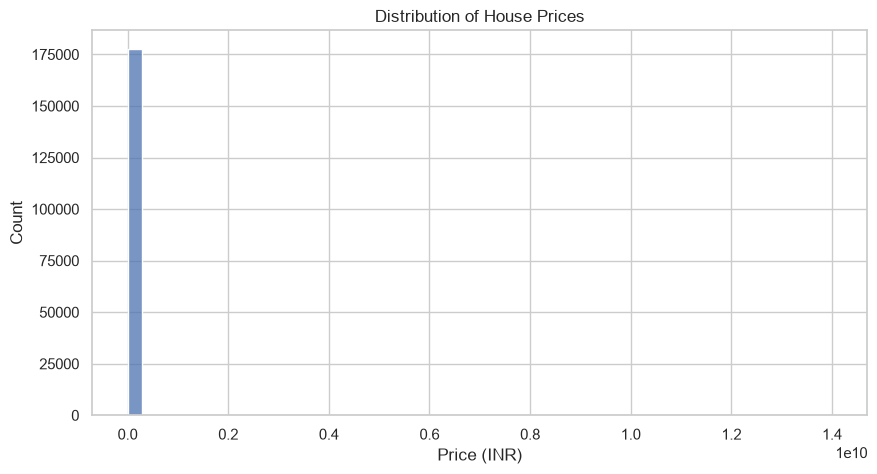

In [18]:
plt.figure(figsize=(10, 5))

sns.histplot(df["Price_INR"], bins=50)

plt.title("Distribution of House Prices")
plt.xlabel("Price (INR)")
plt.ylabel("Count")

plt.show()

# 15. Boxplot of the Target Variable

A boxplot provides a compact summary of the target variable and highlights potential outliers.

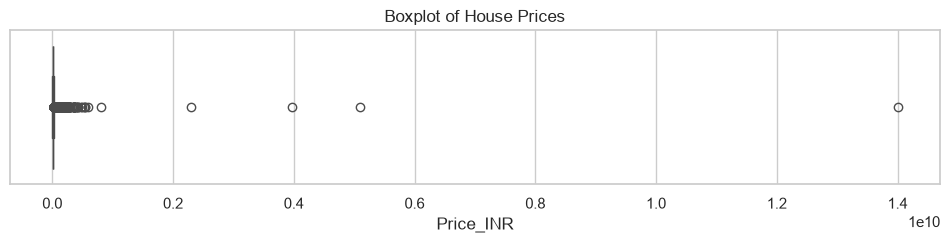

In [19]:
plt.figure(figsize=(12, 2))

sns.boxplot(x=df["Price_INR"])

plt.title("Boxplot of House Prices")

plt.show()

# 16. Log Transformation of the Target Variable

The house prices are highly right-skewed because a small number of luxury properties have extremely high prices.

To better visualize the distribution, we apply a logarithmic transformation.

The log transformation compresses very large values while preserving the ordering of the data, making the distribution easier to analyze.

In [20]:
df["Log_Price"] = np.log1p(df["Price_INR"])

## Distribution After Log Transformation

The following histogram shows the distribution after applying the logarithmic transformation.

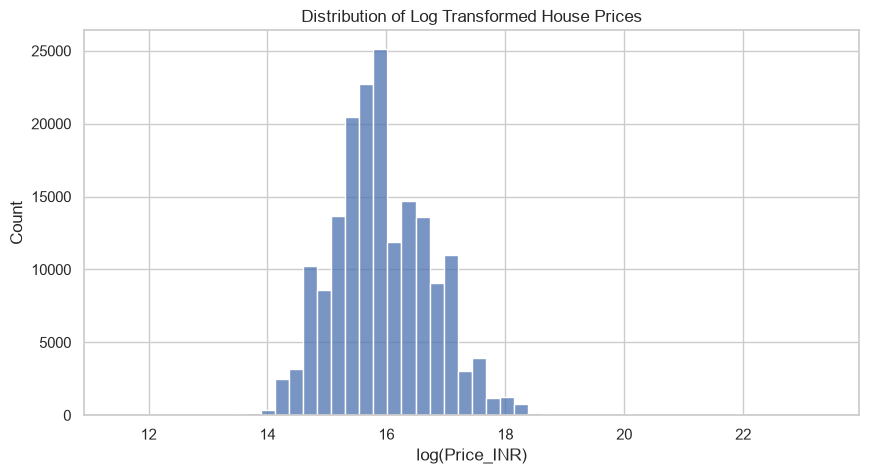

In [21]:
plt.figure(figsize=(10,5))

sns.histplot(df["Log_Price"], bins=50)

plt.title("Distribution of Log Transformed House Prices")

plt.xlabel("log(Price_INR)")

plt.ylabel("Count")

plt.show()

## Boxplot After Log Transformation

The boxplot after logarithmic transformation provides a clearer visualization of the spread of the data.

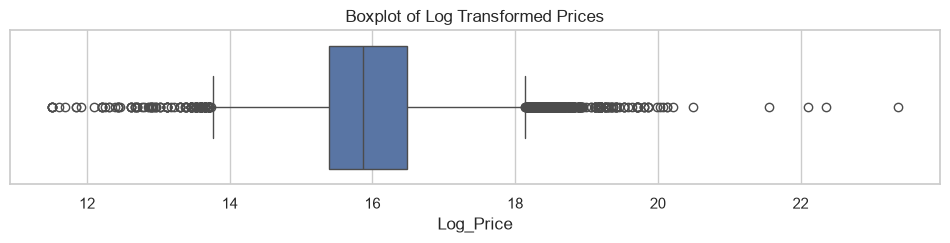

In [22]:
plt.figure(figsize=(12,2))

sns.boxplot(x=df["Log_Price"])

plt.title("Boxplot of Log Transformed Prices")

plt.show()

# 17. Observations

### Original Target Variable (`Price_INR`)

- The target variable was successfully converted from text (Lac/Cr) into numeric values (INR).
- The original distribution is highly right-skewed.
- Several extremely expensive properties produce significant outliers.
- These outliers compress the histogram, making the distribution difficult to interpret.

### Log-Transformed Target Variable (`Log_Price`)

- The logarithmic transformation significantly reduces the skewness.
- The distribution becomes much closer to a normal (bell-shaped) distribution.
- Outliers are still present but have much less influence on the visualization.
- Log transformation may improve the performance of regression models such as Linear Regression, Ridge, and Lasso.

### Conclusion

For exploratory analysis, the logarithmic transformation provides a much clearer view of the data distribution. During model development, we will compare models trained on both the original target and the log-transformed target to determine which produces better prediction accuracy.